# Cobblestone Gifts — Cleaning & Analysing the Online Retail Dataset

**Mini-Project #01**

In [1]:
import os
import re
import time
import json
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 60)
np.random.seed(0)
sns.set_theme(style="whitegrid")

print("pandas", pd.__version__, "| numpy", np.__version__)

RAW_PATH = "data.csv"
CLEAN_PATH = "clean_online_retail.csv"
FIG_DIR = "."
os.makedirs(FIG_DIR, exist_ok=True)

metrics = {}

pandas 2.3.3 | numpy 2.2.6


## Load & profile

### 3.2 Getting information

The file is **not UTF-8** — it must be read with `encoding="ISO-8859-1"` or it crashes
on the `£` symbol. If the raw file is missing on a fresh clone, we fall back to
downloading it from Kaggle with `kagglehub` (the same approach used in the lecture).

In [2]:
if not os.path.exists(RAW_PATH):
    import kagglehub
    dl = kagglehub.dataset_download("carrie1/ecommerce-data")
    os.makedirs(os.path.dirname(RAW_PATH) or ".", exist_ok=True)
    shutil.copy(os.path.join(dl, "data.csv"), RAW_PATH)
    print("Downloaded data.csv from Kaggle into", RAW_PATH)

df_raw = pd.read_csv(RAW_PATH, encoding="ISO-8859-1")

print("shape:", df_raw.shape)
display(df_raw.head())

shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [3]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [4]:
display(df_raw.describe())

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [5]:
missing = df_raw.isnull().sum()
display(missing[missing > 0])

metrics["raw_rows"] = int(df_raw.shape[0])
metrics["raw_cols"] = int(df_raw.shape[1])
metrics["missing_customer_id"] = int(df_raw["CustomerID"].isnull().sum())
metrics["missing_customer_id_pct"] = round(df_raw["CustomerID"].isnull().mean() * 100, 1)
metrics["missing_description"] = int(df_raw["Description"].isnull().sum())
print(metrics["missing_customer_id"], "rows have no CustomerID "
      f"(~{metrics['missing_customer_id_pct']}%); "
      f"{metrics['missing_description']} rows have a blank Description.")

Description      1454
CustomerID     135080
dtype: int64

135080 rows have no CustomerID (~24.9%); 1454 rows have a blank Description.


**Read-out.** ~541k rows × 8 columns. `CustomerID` is missing on ~25% of rows and
`Description` on ~1.5k rows. `UnitPrice`/`Quantity` `describe()` already shows negative
minimums — a sign that returns and adjustment lines are mixed in with real sales.

### 3.9 Unique values

`value_counts()` / `nunique()` on the categorical columns surface non-product codes
(POST, DOT, M, BANK CHARGES, AMAZONFEE, …) and, with `dropna=False`, expose missing
entries directly.

In [6]:
print("distinct countries:", df_raw["Country"].nunique())
print("distinct stock codes:", df_raw["StockCode"].nunique())
print("distinct descriptions:", df_raw["Description"].nunique())

display(df_raw["Country"].value_counts().head(10))

distinct countries: 38
distinct stock codes: 4070
distinct descriptions: 4223


Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         2002
Portugal            1519
Australia           1259
Name: count, dtype: int64

In [7]:
non_numeric_codes = (
    df_raw.loc[~df_raw["StockCode"].astype(str).str.match(r"^\d{5}"), "StockCode"]
    .value_counts()
    .head(15)
)
display(non_numeric_codes)

StockCode
POST            1256
DOT              710
M                571
C2               144
D                 77
S                 63
BANK CHARGES      37
AMAZONFEE         34
CRUK              16
DCGSSGIRL         13
DCGSSBOY          11
gift_0001_20      10
gift_0001_10       9
gift_0001_30       8
DCGS0003           5
Name: count, dtype: int64

In [8]:
display(df_raw["Description"].value_counts(dropna=False).head(8))

Description
WHITE HANGING HEART T-LIGHT HOLDER    2369
REGENCY CAKESTAND 3 TIER              2200
JUMBO BAG RED RETROSPOT               2159
PARTY BUNTING                         1727
LUNCH BAG RED RETROSPOT               1638
ASSORTED COLOUR BIRD ORNAMENT         1501
SET OF 3 CAKE TINS PANTRY DESIGN      1473
NaN                                   1454
Name: count, dtype: int64

**Read-out.** 38 countries (UK dominates). Beyond real 5-digit product codes there are
service/adjustment codes — `POST`, `DOT`, `M`, `BANK CHARGES`, `AMAZONFEE`, `C2`,
`PADS`, `D` — which are not products and must be removed for a sales analysis.

### 3.8 Min/max/sum/mean/count

Summary stats for `Quantity` and `UnitPrice` quantify the bad data: negative quantities
(returns) and zero/negative prices (adjustments/errors) that cannot be valid sales.

In [9]:
summary = df_raw[["Quantity", "UnitPrice"]].agg(["min", "max", "sum", "mean", "count"])
display(summary)

neg_qty = int((df_raw["Quantity"] <= 0).sum())
nonpos_price = int((df_raw["UnitPrice"] <= 0).sum())
print(f"Quantity <= 0 : {neg_qty:,} rows (returns / adjustments)")
print(f"UnitPrice <= 0: {nonpos_price:,} rows (cannot be valid sales)")

,Quantity,UnitPrice
min,-8.099500e+04,-1.106206e+04
max,8.099500e+04,3.897000e+04
sum,5.176450e+06,2.498804e+06
mean,9.552250e+00,4.611114e+00
count,5.419090e+05,5.419090e+05


Quantity <= 0 : 10,624 rows (returns / adjustments)
UnitPrice <= 0: 2,517 rows (cannot be valid sales)


### 3.1 Creating a DataFrame

Build a small **country → region** lookup *from a Python dictionary*. We keep it as
`region_lookup` and merge it back at **3.21** to answer the markets question by region.

In [10]:
region_map = {
    # UK & Ireland
    "United Kingdom": "UK&IE", "Ireland": "UK&IE", "EIRE": "UK&IE",
    # Western Europe
    "France": "Western Europe", "Germany": "Western Europe", "Netherlands": "Western Europe",
    "Spain": "Western Europe", "Belgium": "Western Europe", "Switzerland": "Western Europe",
    "Portugal": "Western Europe", "Italy": "Western Europe", "Austria": "Western Europe",
    "Denmark": "Western Europe", "Sweden": "Western Europe", "Norway": "Western Europe",
    "Finland": "Western Europe", "Iceland": "Western Europe", "Poland": "Western Europe",
    "Czech Republic": "Western Europe", "Lithuania": "Western Europe", "Greece": "Western Europe",
    "Cyprus": "Western Europe", "Malta": "Western Europe", "Channel Islands": "Western Europe",
    "European Community": "Western Europe",
    # North America
    "USA": "North America", "Canada": "North America",
    # APAC
    "Australia": "APAC", "Japan": "APAC", "Hong Kong": "APAC", "Singapore": "APAC",
    # Middle East
    "Israel": "Middle East", "Bahrain": "Middle East", "Lebanon": "Middle East",
    "United Arab Emirates": "Middle East", "Saudi Arabia": "Middle East",
    # Rest of world
    "Brazil": "South America", "South Africa": "Africa", "RSA": "Africa",
}
region_lookup = pd.DataFrame(
    {"country": list(region_map.keys()), "region": list(region_map.values())}
)
print("region_lookup shape:", region_lookup.shape)
display(region_lookup.head())

region_lookup shape: (39, 2)


,country,region
0,United Kingdom,UK&IE
1,Ireland,UK&IE
2,EIRE,UK&IE
3,France,Western Europe
4,Germany,Western Europe


# Select & filter

Inspect rows, isolate the problem groups, and rank to see the extremes *before* we
remove anything.

### 3.3 Slicing

Use `iloc` for positional ranges, then create a unique line-item index (`line_id`) and
retrieve rows by label with `loc`. From here on we work on `df`, a **fresh copy** of the
raw frame — `df_raw` stays pristine.

In [11]:
display(df_raw.iloc[0:5])

df = df_raw.copy()
df = df.reset_index().rename(columns={"index": "line_id"})

display(df.loc[0:3, ["line_id", "InvoiceNo", "StockCode", "Quantity", "UnitPrice"]])

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


,line_id,InvoiceNo,StockCode,Quantity,UnitPrice
0,0,536365,85123A,6,2.55
1,1,536365,71053,6,3.39
2,2,536365,84406B,8,2.75
3,3,536365,84029G,6,3.39


### 3.4 Conditional selection

Isolate and **count** the three problem groups. Cancellations carry an `InvoiceNo`
beginning with `"C"`. We also save the cancellations/returns subset as `df_returns`
for Question 6 *before* we drop them.

In [12]:
is_cancel = df["InvoiceNo"].astype(str).str.startswith("C")
n_cancel = int(is_cancel.sum())
n_qty_le0 = int((df["Quantity"] <= 0).sum())
n_price_le0 = int((df["UnitPrice"] <= 0).sum())

print(f"cancellations (InvoiceNo starts 'C'): {n_cancel:,}")
print(f"Quantity <= 0                       : {n_qty_le0:,}")
print(f"UnitPrice <= 0                       : {n_price_le0:,}")

df_returns = df[is_cancel | (df["Quantity"] < 0)].copy()
print("df_returns rows:", df_returns.shape[0])

metrics["cancellation_rows"] = n_cancel
metrics["qty_le0_rows"] = n_qty_le0
metrics["price_le0_rows"] = n_price_le0
metrics["returns_rows"] = int(df_returns.shape[0])

cancellations (InvoiceNo starts 'C'): 9,288
Quantity <= 0                       : 10,624
UnitPrice <= 0                       : 2,517
df_returns rows: 10624


### 3.5 Sorting values

Sort by `Quantity` and by line revenue (`Quantity * UnitPrice`) to surface the largest
bulk orders and the largest returns.

In [13]:
line_rev = df["Quantity"] * df["UnitPrice"]
ranked = df.assign(line_revenue=line_rev)

print("Largest bulk orders (top quantities):")
display(ranked.sort_values("Quantity", ascending=False)
        [["InvoiceNo", "Description", "Quantity", "UnitPrice", "line_revenue"]].head(5))

print("Largest returns (most negative line revenue):")
display(ranked.sort_values("line_revenue", ascending=True)
        [["InvoiceNo", "Description", "Quantity", "UnitPrice", "line_revenue"]].head(5))

Largest bulk orders (top quantities):


,InvoiceNo,Description,Quantity,UnitPrice,line_revenue
540421,581483,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,168469.6
61619,541431,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,77183.6
502122,578841,ASSTD DESIGN 3D PAPER STICKERS,12540,0.00,0.0
74614,542504,NaN,5568,0.00,0.0
421632,573008,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,0.21,1008.0


Largest returns (most negative line revenue):


,InvoiceNo,Description,Quantity,UnitPrice,line_revenue
540422,C581484,"PAPER CRAFT , LITTLE BIRDIE",-80995,2.08,-168469.60
61624,C541433,MEDIUM CERAMIC TOP STORAGE JAR,-74215,1.04,-77183.60
222681,C556445,Manual,-1,38970.00,-38970.00
524602,C580605,AMAZON FEE,-1,17836.46,-17836.46
43702,C540117,AMAZON FEE,-1,16888.02,-16888.02


## Clean & fix

Standardise labels, rename columns, set missing-value policy, and build the clean
completed-sales frame.

### 3.6 Replacing values

Standardise country labels with `.replace()` (assigned to a new frame — no `inplace`):
`EIRE → Ireland`, `RSA → South Africa`, `Unspecified → NaN`.

In [14]:
df = df.replace({"Country": {"EIRE": "Ireland", "RSA": "South Africa",
                             "Unspecified": np.nan}})
print("countries now:", df["Country"].nunique(),
      "| 'EIRE' remaining:", int((df["Country"] == "EIRE").sum()))

countries now: 37 | 'EIRE' remaining: 0


### 3.7 Renaming columns

Rename every column to snake_case. The map is reused later when we standardise the
`df_returns` subset for Question 6.

In [15]:
COLMAP = {
    "InvoiceNo": "invoice_no", "StockCode": "stock_code", "Description": "description",
    "Quantity": "quantity", "InvoiceDate": "invoice_date", "UnitPrice": "unit_price",
    "CustomerID": "customer_id", "Country": "country",
}
df = df.rename(columns=COLMAP)
print(list(df.columns))

['line_id', 'invoice_no', 'stock_code', 'description', 'quantity', 'invoice_date', 'unit_price', 'customer_id', 'country']


### 3.10 Handling missing values

Quantify missingness, then **decide and justify** a policy. We demonstrate `isnull()`,
`fillna()`, and `dropna()`.

**Policy.**
* **Missing `customer_id` (~25%)** — these are still legitimate completed sales (the
  till simply didn't capture a loyalty ID), so we **keep them** in the sales dataset for
  revenue / product / time questions, and only restrict to identified customers
  (`df_identified`) for customer-level questions. We add a `has_customer` flag.
* **Blank `description` (~1.5k)** — these overwhelmingly coincide with the zero-price
  adjustment/error lines we remove anyway, so we **drop them** with `dropna()`.

In [16]:
display(df.isnull().sum())
print("missing customer_id share:", round(df["customer_id"].isnull().mean() * 100, 1), "%")

demo_filled = df["customer_id"].fillna(-1)
print("after an illustrative fillna(-1), remaining missing customer_id:",
      int(demo_filled.isnull().sum()))

df = df.assign(has_customer=df["customer_id"].notna())
before = df.shape[0]
df = df.dropna(subset=["description"])
print(f"dropped {before - df.shape[0]:,} blank-description rows; now {df.shape[0]:,} rows")

line_id              0
invoice_no           0
stock_code           0
description       1454
quantity             0
invoice_date         0
unit_price           0
customer_id     135080
country            446
dtype: int64

missing customer_id share: 24.9 %
after an illustrative fillna(-1), remaining missing customer_id: 0
dropped 1,454 blank-description rows; now 540,455 rows


### 3.11 Deleting a column

`line_id` was useful for the `loc`/`iloc` demonstrations at 3.3 but adds no analytical
value downstream, so we drop it.

In [17]:
df = df.drop(columns=["line_id"])
print("columns after drop:", list(df.columns))

columns after drop: ['invoice_no', 'stock_code', 'description', 'quantity', 'invoice_date', 'unit_price', 'customer_id', 'country', 'has_customer']


### 3.12 Deleting a row

Build the clean **completed-sales** frame `df_sales` by removing:
* cancellations (`invoice_no` starts with `C`),
* non-product lines — keep only 5-digit stock codes (`^\d{5}`, optionally a letter
  suffix), which drops POST, DOT, M, BANK CHARGES, AMAZONFEE, C2, PADS, D, etc.,
* impossible prices/quantities (`quantity <= 0`, `unit_price <= 0`).

In [18]:
is_cancel_s = df["invoice_no"].astype(str).str.startswith("C")
is_product = df["stock_code"].astype(str).str.match(r"^\d{5}")

dropped_codes = (df.loc[~is_product & ~is_cancel_s, "stock_code"]
                 .value_counts().head(20))
print("Non-product codes dropped (top):")
display(dropped_codes)

df_sales = df[(~is_cancel_s) & is_product &
              (df["quantity"] > 0) & (df["unit_price"] > 0)].copy()

metrics["nonproduct_rows"] = int((~is_product).sum())
print("rows before sales filters:", df.shape[0])
print("rows after  sales filters:", df_sales.shape[0])

Non-product codes dropped (top):


stock_code
POST            1126
DOT              708
M                327
C2               141
DCGSSGIRL         13
BANK CHARGES      12
DCGSSBOY          11
gift_0001_20      10
gift_0001_10       8
gift_0001_30       7
DCGS0003           5
gift_0001_50       4
PADS               4
gift_0001_40       3
B                  3
DCGS0069           2
DCGS0076           2
AMAZONFEE          2
S                  2
m                  1
Name: count, dtype: int64

rows before sales filters: 540455
rows after  sales filters: 527725


### 3.13 Dropping duplicates

Detect exact duplicate lines with `duplicated().sum()`, then remove them with
`drop_duplicates()` and **report how many rows were dropped**.

In [19]:
n_dupes = int(df_sales.duplicated().sum())
before = df_sales.shape[0]
df_sales = df_sales.drop_duplicates()
print(f"exact duplicate rows: {n_dupes:,}")
print(f"dropped {before - df_sales.shape[0]:,} rows; df_sales now {df_sales.shape[0]:,} rows")

metrics["duplicate_rows_dropped"] = before - df_sales.shape[0]
metrics["clean_rows"] = int(df_sales.shape[0])

df_identified = df_sales.dropna(subset=["customer_id"]).copy()
print("df_identified rows:", df_identified.shape[0],
      "| distinct customers:", df_identified["customer_id"].nunique())
metrics["identified_rows"] = int(df_identified.shape[0])

exact duplicate rows: 5,221
dropped 5,221 rows; df_sales now 522,504 rows
df_identified rows: 391150 | distinct customers: 4334


## Engineer & summarise

Add a revenue column, then group/aggregate to describe the business.

### 3.18 Applying a function

Add `revenue = quantity * unit_price` (vectorised), use `apply` to tidy `description`
(strip + title-case), and use `apply` to flag cancelled invoices (a sanity check — none
should remain in `df_sales`).

In [20]:
df_sales = df_sales.assign(revenue=df_sales["quantity"] * df_sales["unit_price"])

df_sales = df_sales.assign(
    description=df_sales["description"].apply(lambda s: str(s).strip().title())
)


df_identified = df_sales.dropna(subset=["customer_id"]).copy()

cancel_flag = df_sales["invoice_no"].apply(lambda x: str(x).startswith("C"))
print("cancelled invoices remaining in df_sales:", int(cancel_flag.sum()), "(should be 0)")
display(df_sales[["invoice_no", "description", "quantity", "unit_price", "revenue"]].head())

cancelled invoices remaining in df_sales: 0 (should be 0)


,invoice_no,description,quantity,unit_price,revenue
0,536365,White Hanging Heart T-Light Holder,6,2.55,15.30
1,536365,White Metal Lantern,6,3.39,20.34
2,536365,Cream Cupid Hearts Coat Hanger,8,2.75,22.00
3,536365,Knitted Union Flag Hot Water Bottle,6,3.39,20.34
4,536365,Red Woolly Hottie White Heart.,6,3.39,20.34


### 3.17 Looping over a column

We can derive a column with an explicit Python `for`-loop / list comprehension, but for
500k+ rows that is slow. Below we time a loop against the vectorised equivalent to show
why `apply`/vectorisation is preferred.

In [21]:
sample = df_sales["revenue"].to_numpy()

t0 = time.perf_counter()
bands_loop = ["big" if r >= 20 else ("medium" if r >= 5 else "small") for r in sample]
t_loop = time.perf_counter() - t0

t0 = time.perf_counter()
bands_vec = np.where(sample >= 20, "big", np.where(sample >= 5, "medium", "small"))
t_vec = time.perf_counter() - t0

print(f"loop:       {t_loop*1000:8.1f} ms")
print(f"vectorised: {t_vec*1000:8.1f} ms")
print(f"vectorised is ~{t_loop / max(t_vec, 1e-9):.0f}x faster; results match:",
      list(bands_loop) == list(bands_vec))

loop:           40.5 ms
vectorised:     13.4 ms
vectorised is ~3x faster; results match: True


**Takeaway.** Identical result, but the vectorised path is dramatically faster and
clearer. Prefer vectorised ops / `apply` over row-by-row Python loops.

### 3.14 Grouping by values

`groupby` for revenue by `country` and number of orders per customer.

In [22]:
rev_by_country = (df_sales.groupby("country")["revenue"].sum()
                  .sort_values(ascending=False))
display(rev_by_country.head(10))

orders_per_customer = df_identified.groupby("customer_id")["invoice_no"].nunique()
print("median orders per identified customer:", float(orders_per_customer.median()))

country
United Kingdom    8724045.22
Netherlands        283889.34
Ireland            270850.86
Germany            205381.15
France             184493.00
Australia          138103.81
Spain               55706.56
Switzerland         53065.60
Japan               37416.37
Belgium             36927.34
Name: revenue, dtype: float64

median orders per identified customer: 2.0


### 3.16 Aggregating

`agg` to produce several statistics at once — total revenue, mean order value, and
transaction (line) count — per country and per customer.

In [23]:
country_stats = (df_sales.groupby("country")
                 .agg(total_revenue=("revenue", "sum"),
                      mean_line_value=("revenue", "mean"),
                      lines=("revenue", "count"))
                 .sort_values("total_revenue", ascending=False))
display(country_stats.head(10))

customer_stats = (df_identified.groupby("customer_id")
                  .agg(total_spend=("revenue", "sum"),
                       orders=("invoice_no", "nunique"),
                       lines=("revenue", "count")))
display(customer_stats.sort_values("total_spend", ascending=False).head(5))

,total_revenue,mean_line_value,lines
country,,,
United Kingdom,8724045.22,18.219200,478838
Netherlands,283889.34,122.260698,2322
Ireland,270850.86,34.867515,7768
Germany,205381.15,23.762715,8643
France,184493.00,22.819171,8085
Australia,138103.81,117.037127,1180
Spain,55706.56,23.047811,2417
Switzerland,53065.60,27.537935,1927
Japan,37416.37,116.561900,321


,total_spend,orders,lines
customer_id,,,
14646.0,279138.02,72,2060
18102.0,259657.30,60,431
17450.0,194390.79,46,336
16446.0,168472.50,2,3
14911.0,136161.83,198,5584


### 3.19 Applying to groups

`groupby(...).apply(...)` for a custom per-customer summary: total spend and the number
of distinct active months.

In [24]:
def customer_summary(g):
    months = pd.to_datetime(g["invoice_date"], format="%m/%d/%Y %H:%M").dt.to_period("M")
    return pd.Series({"total_spend": g["revenue"].sum(),
                      "active_months": months.nunique()})

per_customer = (df_identified.groupby("customer_id")
                .apply(customer_summary, include_groups=False))
display(per_customer.sort_values("total_spend", ascending=False).head(5))

,total_spend,active_months
customer_id,,
14646.0,279138.02,13.0
18102.0,259657.30,12.0
17450.0,194390.79,12.0
16446.0,168472.50,2.0
14911.0,136161.83,13.0


### 3.15 Grouping by time

Parse `invoice_date` to datetime, set it as the index, and `resample` monthly (and
weekly) to chart the revenue trend.

In [25]:
ts = df_sales.assign(
    invoice_date=pd.to_datetime(df_sales["invoice_date"], format="%m/%d/%Y %H:%M")
).set_index("invoice_date")

monthly_revenue = ts["revenue"].resample("M").sum()
weekly_revenue = ts["revenue"].resample("W").sum()

display(monthly_revenue)
print("weeks covered:", weekly_revenue.shape[0])

/var/folders/gk/tgkhvr0n5njg4ql47661fv5w0000gp/T/ipykernel_48088/4160790157.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_revenue = ts["revenue"].resample("M").sum()


invoice_date
2010-12-31     775572.23
2011-01-31     670361.99
2011-02-28     507783.42
2011-03-31     689708.49
2011-04-30     515354.78
2011-05-31     739914.35
2011-06-30     737558.98
2011-07-31     688144.79
2011-08-31     724196.76
2011-09-30    1028313.80
2011-10-31    1103310.96
2011-11-30    1452112.69
2011-12-31     614487.63
Freq: ME, Name: revenue, dtype: float64

weeks covered: 54


## Combine

Recombine split extracts and merge in the region lookup.

### 3.20 Concatenating

Split the clean data into first-half vs second-half of the year and `concat` it back,
simulating the merge of two monthly extracts. Row counts must match.

In [26]:
order_dt = pd.to_datetime(df_sales["invoice_date"], format="%m/%d/%Y %H:%M")
h1 = df_sales[order_dt < "2011-07-01"]
h2 = df_sales[order_dt >= "2011-07-01"]
recombined = pd.concat([h1, h2], axis=0)

print(f"H1 rows: {h1.shape[0]:,} | H2 rows: {h2.shape[0]:,} | "
      f"concat: {recombined.shape[0]:,} | original: {df_sales.shape[0]:,}")
print("row counts match:", recombined.shape[0] == df_sales.shape[0])

H1 rows: 236,732 | H2 rows: 285,772 | concat: 522,504 | original: 522,504
row counts match: True


### 3.21 Merging

`merge` the `region_lookup` to add a `region` column. We compare an **inner** vs a
**left** join and note which countries fail to match (labelling any gaps `Other`).

In [27]:
inner = df_sales.merge(region_lookup, on="country", how="inner")
left = df_sales.merge(region_lookup, on="country", how="left")

print(f"inner-join rows: {inner.shape[0]:,} | left-join rows: {left.shape[0]:,}")
unmatched = sorted(left.loc[left["region"].isna(), "country"].dropna().unique().tolist())
print("countries with no region match:", unmatched if unmatched else "none")

df_sales = left.assign(region=left["region"].fillna("Other"))
display(df_sales[["invoice_no", "country", "region", "revenue"]].head())

inner-join rows: 522,062 | left-join rows: 522,504
countries with no region match: none


,invoice_no,country,region,revenue
0,536365,United Kingdom,UK&IE,15.30
1,536365,United Kingdom,UK&IE,20.34
2,536365,United Kingdom,UK&IE,22.00
3,536365,United Kingdom,UK&IE,20.34
4,536365,United Kingdom,UK&IE,20.34


### Export the clean completed-sales dataset

In [28]:
df_sales.to_csv(CLEAN_PATH, index=False)
print("wrote", CLEAN_PATH, "with shape", df_sales.shape)

wrote clean_online_retail.csv with shape (522504, 11)


# Part 2 — Business questions

Each answer uses `df_sales` (completed sales) for revenue/product/time questions and
`df_identified` for customer-specific parts (with the missing-ID caveat noted).

## Q1 · Seasonality

Total revenue for the year, the monthly breakdown, the peak trading season, and the lift
versus the average month.

Total revenue for the year: £10,246,821
Peak month: November 2011 at £1,452,113
Average month: £788,217  ->  peak is +84.2% vs the average month


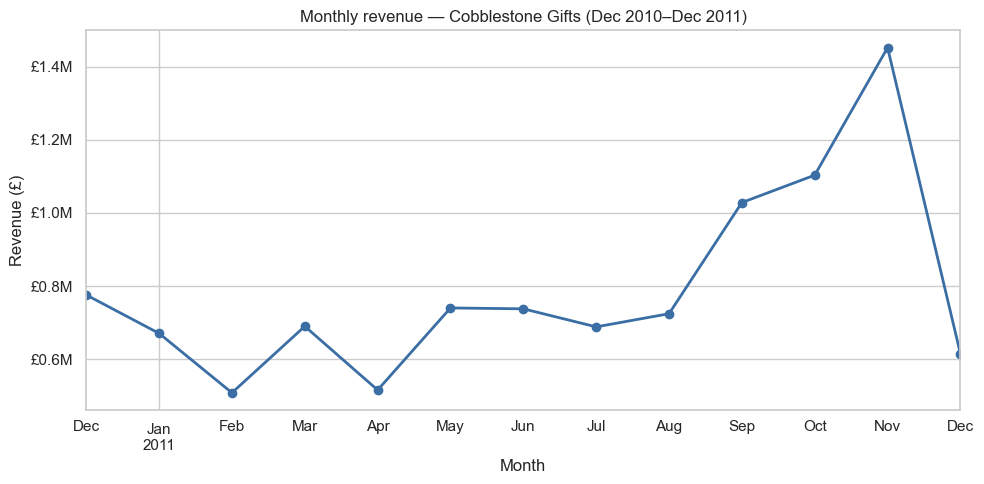

In [29]:
total_revenue = float(df_sales["revenue"].sum())
peak_month = monthly_revenue.idxmax()
peak_value = float(monthly_revenue.max())
avg_month = float(monthly_revenue.mean())
lift_pct = round((peak_value / avg_month - 1) * 100, 1)

print(f"Total revenue for the year: £{total_revenue:,.0f}")
print(f"Peak month: {peak_month:%B %Y} at £{peak_value:,.0f}")
print(f"Average month: £{avg_month:,.0f}  ->  peak is +{lift_pct}% vs the average month")

metrics.update(total_revenue=total_revenue,
               peak_month=f"{peak_month:%B %Y}",
               peak_revenue=peak_value, avg_month_revenue=avg_month,
               peak_lift_pct=lift_pct)

fig, ax = plt.subplots(figsize=(10, 5))
monthly_revenue.plot(ax=ax, marker="o", color="#3a6ea5", linewidth=2)
ax.set_title("Monthly revenue — Cobblestone Gifts (Dec 2010–Dec 2011)")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue (£)")
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda v, _: f"£{v/1e6:.1f}M"))
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/monthly_revenue_trend.png", dpi=150, bbox_inches="tight")
plt.show()

**Answer.** Revenue climbs steadily through the autumn and peaks in the pre-Christmas
trading season — see the chart and the printed lift above.

## Q2 · Best sellers

Top 10 products by revenue and top 10 by units sold. Are the lists the same, and what
does any difference say about pricing?

Top 10 by REVENUE:


description
Regency Cakestand 3 Tier              174156.54
Paper Craft , Little Birdie           168469.60
White Hanging Heart T-Light Holder    106236.72
Party Bunting                          99445.23
Jumbo Bag Red Retrospot                94159.81
Medium Ceramic Top Storage Jar         81700.92
Rabbit Night Light                     66870.03
Paper Chain Kit 50'S Christmas         64875.59
Assorted Colour Bird Ornament          58927.62
Chilli Lights                          54096.36
Name: revenue, dtype: float64

Top 10 by UNITS:


description
Paper Craft , Little Birdie           80995
Medium Ceramic Top Storage Jar        78033
World War 2 Gliders Asstd Designs     54951
Jumbo Bag Red Retrospot               48371
White Hanging Heart T-Light Holder    37872
Popcorn Holder                        36749
Pack Of 72 Retrospot Cake Cases       36396
Assorted Colour Bird Ornament         36362
Rabbit Night Light                    30739
Mini Paint Set Vintage                26633
Name: quantity, dtype: int64

products on BOTH lists: 6 -> ['Assorted Colour Bird Ornament', 'Jumbo Bag Red Retrospot', 'Medium Ceramic Top Storage Jar', 'Paper Craft , Little Birdie', 'Rabbit Night Light', 'White Hanging Heart T-Light Holder']


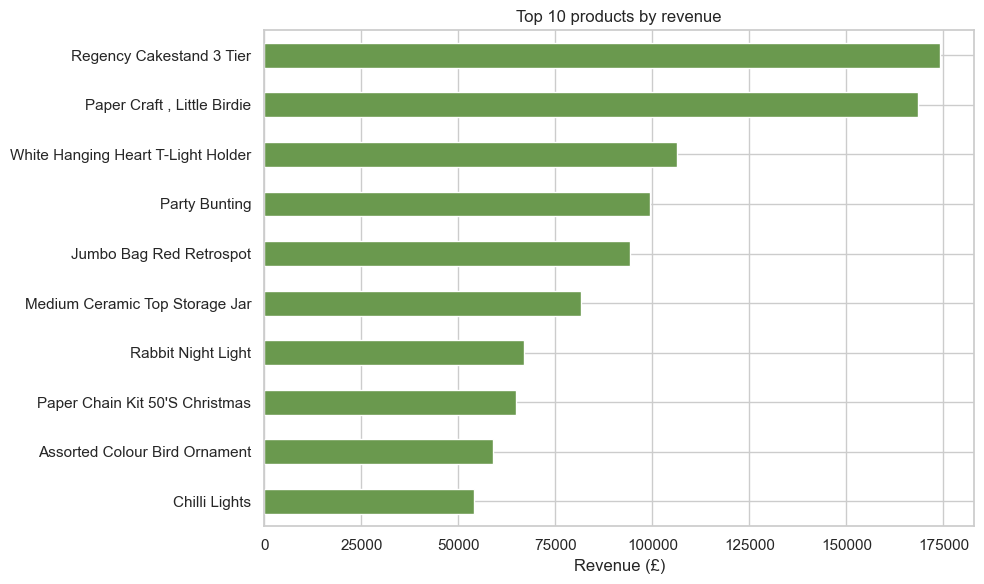

In [30]:
by_revenue = (df_sales.groupby("description")["revenue"].sum()
              .sort_values(ascending=False).head(10))
by_units = (df_sales.groupby("description")["quantity"].sum()
            .sort_values(ascending=False).head(10))

print("Top 10 by REVENUE:")
display(by_revenue)
print("Top 10 by UNITS:")
display(by_units)

overlap = sorted(set(by_revenue.index) & set(by_units.index))
print(f"products on BOTH lists: {len(overlap)} -> {overlap}")

metrics["top_products_revenue"] = {k: round(float(v), 2) for k, v in by_revenue.items()}
metrics["top_products_units"] = {k: int(v) for k, v in by_units.items()}
metrics["bestseller_overlap"] = len(overlap)

fig, ax = plt.subplots(figsize=(10, 6))
by_revenue.sort_values().plot(kind="barh", ax=ax, color="#6a994e")
ax.set_title("Top 10 products by revenue")
ax.set_xlabel("Revenue (£)")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/top_products_revenue.png", dpi=150, bbox_inches="tight")
plt.show()

**Answer.** The two lists overlap only partially. High-revenue items are a mix of
moderately priced decor lines, while the unit-leaders skew to cheap, high-volume novelty
items — i.e. revenue is driven by price × volume, not volume alone.

## Q3 · Markets

Outside the UK, the most valuable **countries** and **regions** by revenue and by number
of distinct customers.

Top non-UK countries by revenue:


country
Netherlands    283889.34
Ireland        270850.86
Germany        205381.15
France         184493.00
Australia      138103.81
Spain           55706.56
Switzerland     53065.60
Japan           37416.37
Belgium         36927.34
Sweden          36828.83
Name: revenue, dtype: float64

Top non-UK countries by distinct customers:


country
Germany        94
France         87
Spain          30
Belgium        25
Switzerland    21
Portugal       19
Italy          14
Finland        12
Austria        11
Norway         10
Name: customer_id, dtype: int64

Top regions (excl. UK&IE) by revenue:


region
Western Europe    1031369.22
APAC               194384.76
Middle East         12588.13
North America        6695.83
Other                4740.94
Name: revenue, dtype: float64

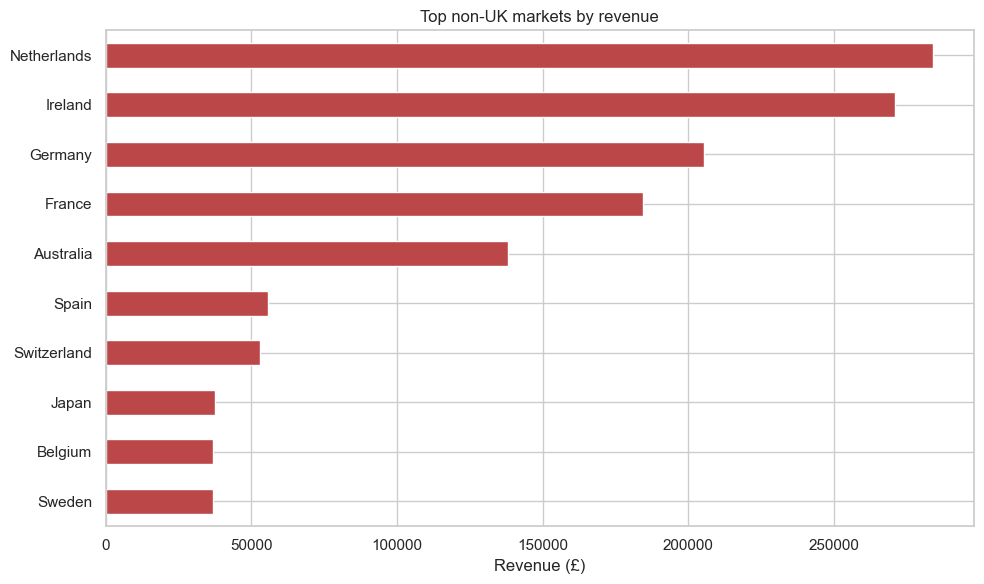

In [31]:
non_uk = df_sales[df_sales["country"] != "United Kingdom"]

country_rev = non_uk.groupby("country")["revenue"].sum().sort_values(ascending=False)
country_cust = (non_uk.dropna(subset=["customer_id"])
                .groupby("country")["customer_id"].nunique()
                .sort_values(ascending=False))
region_rev = (df_sales[df_sales["region"] != "UK&IE"]
              .groupby("region")["revenue"].sum().sort_values(ascending=False))

print("Top non-UK countries by revenue:")
display(country_rev.head(10))
print("Top non-UK countries by distinct customers:")
display(country_cust.head(10))
print("Top regions (excl. UK&IE) by revenue:")
display(region_rev.head())

metrics["top_country_rev"] = {k: round(float(v), 0) for k, v in country_rev.head(5).items()}
metrics["top_country_cust"] = {k: int(v) for k, v in country_cust.head(5).items()}
metrics["top_region_rev"] = {k: round(float(v), 0) for k, v in region_rev.head(5).items()}

fig, ax = plt.subplots(figsize=(10, 6))
country_rev.head(10).sort_values().plot(kind="barh", ax=ax, color="#bc4749")
ax.set_title("Top non-UK markets by revenue")
ax.set_xlabel("Revenue (£)")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig(f"{FIG_DIR}/top_markets.png", dpi=150, bbox_inches="tight")
plt.show()

**Answer.** The strongest overseas markets are concentrated in Western Europe (notably
the Netherlands, Ireland, Germany and France). Expansion effort is best aimed at the
top-revenue Western-European countries, which also carry the most distinct customers.

## Q4 · Customer concentration

Top 10 customers by total spend, and the revenue share of the **top 1%** of identified
customers. Is this wholesale-driven?

In [32]:
spend = df_identified.groupby("customer_id")["revenue"].sum().sort_values(ascending=False)
print("Top 10 customers by spend:")
display(spend.head(10))

n_customers = int(spend.shape[0])
n_top1 = max(1, int(np.ceil(n_customers * 0.01)))
top1_share = round(spend.head(n_top1).sum() / spend.sum() * 100, 1)
print(f"identified customers: {n_customers:,}")
print(f"top 1% = {n_top1} customers account for {top1_share}% of identified revenue")

metrics.update(n_identified_customers=n_customers, n_top1pct=n_top1,
               top1pct_revenue_share=top1_share,
               top_customers={int(k): round(float(v), 0) for k, v in spend.head(10).items()})

Top 10 customers by spend:


customer_id
14646.0    279138.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    136161.83
12415.0    124564.53
14156.0    116560.08
17511.0     91062.38
12346.0     77183.60
16029.0     72708.09
Name: revenue, dtype: float64

identified customers: 4,334
top 1% = 44 customers account for 32.2% of identified revenue


**Answer.** A very small group of customers drives a large share of revenue (see the
top-1% figure above) and the biggest accounts buy in bulk — consistent with a
**wholesale-skewed** business rather than purely retail.

## Q5 · Order value

Average order value (revenue per `invoice_no`) overall, and UK vs non-UK.

In [33]:
order_value = df_sales.groupby("invoice_no")["revenue"].sum()
aov = float(order_value.mean())

inv_country = df_sales.groupby("invoice_no")["country"].first()
is_uk_inv = inv_country == "United Kingdom"
aov_uk = float(order_value[is_uk_inv].mean())
aov_non_uk = float(order_value[~is_uk_inv].mean())

print(f"Average order value overall : £{aov:,.2f}")
print(f"  UK orders                 : £{aov_uk:,.2f}")
print(f"  non-UK orders             : £{aov_non_uk:,.2f}")

metrics.update(aov=round(aov, 2), aov_uk=round(aov_uk, 2), aov_non_uk=round(aov_non_uk, 2))

Average order value overall : £518.22
  UK orders                 : £487.35
  non-UK orders             : £813.45


**Answer.** The average basket is well above a typical single-gift purchase, and non-UK
orders are markedly larger than UK orders — again pointing to overseas wholesale buyers.

## Q6 · Returns & cancellations

How common are returns/cancellations by count and by value, using the `df_returns`
subset we saved at 3.4. Which products and customers are most associated with them?

In [34]:
dr = df_returns.rename(columns=COLMAP)
dr = dr.assign(revenue=dr["quantity"] * dr["unit_price"])

returns_count = int(dr.shape[0])
returns_value = float(dr["revenue"].sum())          # negative
returns_pct_count = round(returns_count / metrics["raw_rows"] * 100, 1)
returns_pct_value = round(abs(returns_value) / total_revenue * 100, 1)

print(f"return/cancellation lines: {returns_count:,} "
      f"({returns_pct_count}% of raw rows)")
print(f"value of returns: £{returns_value:,.0f} "
      f"(~{returns_pct_value}% of gross sales revenue)")

top_return_products = (dr.groupby("description")["revenue"].sum()
                       .sort_values().head(5))
top_return_customers = (dr.dropna(subset=["customer_id"])
                        .groupby("customer_id")["revenue"].sum()
                        .sort_values().head(5))
print("Products with the most return value:")
display(top_return_products)
print("Customers with the most return value:")
display(top_return_customers)

metrics.update(returns_count=returns_count, returns_value=round(returns_value, 0),
               returns_pct_count=returns_pct_count, returns_pct_value=returns_pct_value)

return/cancellation lines: 10,624 (2.0% of raw rows)
value of returns: £-896,812 (~8.8% of gross sales revenue)
Products with the most return value:


description
AMAZON FEE                       -235281.59
PAPER CRAFT , LITTLE BIRDIE      -168469.60
Manual                           -146784.46
MEDIUM CERAMIC TOP STORAGE JAR    -77479.64
POSTAGE                           -11871.24
Name: revenue, dtype: float64

Customers with the most return value:


customer_id
16446.0   -168469.60
12346.0    -77183.60
15098.0    -39267.00
16029.0    -30032.23
15749.0    -22998.40
Name: revenue, dtype: float64

**Answer.** Returns/cancellations are a meaningful minority of activity (see the % of
rows and of value above). They concentrate in a handful of high-value lines and a few
bulk accounts — worth monitoring but not pervasive.

## Q7 · Data-quality memo

What share of raw rows we removed or repaired, the assumptions we made, and whether this
is board-report grade. Every percentage is backed by a count.

In [35]:
raw_n = metrics["raw_rows"]
clean_n = metrics["clean_rows"]
removed_n = raw_n - clean_n
pct = lambda n: round(n / raw_n * 100, 1)

print(f"Raw rows                          : {raw_n:,}")
print(f"  cancellations (InvoiceNo 'C')   : {metrics['cancellation_rows']:,} ({pct(metrics['cancellation_rows'])}%)")
print(f"  quantity <= 0                   : {metrics['qty_le0_rows']:,} ({pct(metrics['qty_le0_rows'])}%)")
print(f"  unit_price <= 0                 : {metrics['price_le0_rows']:,} ({pct(metrics['price_le0_rows'])}%)")
print(f"  non-product stock codes         : {metrics['nonproduct_rows']:,} ({pct(metrics['nonproduct_rows'])}%)")
print(f"  blank descriptions              : {metrics['missing_description']:,} ({pct(metrics['missing_description'])}%)")
print(f"  exact duplicate lines           : {metrics['duplicate_rows_dropped']:,} ({pct(metrics['duplicate_rows_dropped'])}%)")
print(f"Clean completed-sales rows        : {clean_n:,} ({pct(clean_n)}% of raw)")
print(f"Net rows removed                  : {removed_n:,} ({pct(removed_n)}% of raw)")
print(f"Rows kept with NO customer_id     : {clean_n - metrics['identified_rows']:,} "
      f"(flagged via has_customer; excluded from customer-level answers)")

metrics.update(removed_rows=removed_n, removed_pct=pct(removed_n), kept_pct=pct(clean_n))

Raw rows                          : 541,909
  cancellations (InvoiceNo 'C')   : 9,288 (1.7%)
  quantity <= 0                   : 10,624 (2.0%)
  unit_price <= 0                 : 2,517 (0.5%)
  non-product stock codes         : 2,980 (0.5%)
  blank descriptions              : 1,454 (0.3%)
  exact duplicate lines           : 5,221 (1.0%)
Clean completed-sales rows        : 522,504 (96.4% of raw)
Net rows removed                  : 19,405 (3.6% of raw)
Rows kept with NO customer_id     : 131,354 (flagged via has_customer; excluded from customer-level answers)


**Answer.** After removing cancellations, non-product lines, impossible prices/
quantities, blank descriptions and exact duplicates, we retain the share printed above
as trustworthy completed sales. Key assumption: rows without a `customer_id` are real
sales and are kept for revenue/product/time analysis but excluded from customer-level
questions. The dataset is **trustworthy for revenue, product, market and seasonality
reporting**. For customer-level claims it should be read with the ~25% missing-ID caveat
in mind, so a board report should footnote that limitation.

### Computed metrics (machine-readable)

The block below is the single source of truth for the numbers quoted in the
`docs/` write-ups.

In [36]:
print("METRICS_JSON_START")
print(json.dumps(metrics, default=str, indent=2))
print("METRICS_JSON_END")

METRICS_JSON_START
{
  "raw_rows": 541909,
  "raw_cols": 8,
  "missing_customer_id": 135080,
  "missing_customer_id_pct": 24.9,
  "missing_description": 1454,
  "cancellation_rows": 9288,
  "qty_le0_rows": 10624,
  "price_le0_rows": 2517,
  "returns_rows": 10624,
  "nonproduct_rows": 2980,
  "duplicate_rows_dropped": 5221,
  "clean_rows": 522504,
  "identified_rows": 391150,
  "total_revenue": 10246820.87,
  "peak_month": "November 2011",
  "peak_revenue": 1452112.69,
  "avg_month_revenue": 788216.99,
  "peak_lift_pct": 84.2,
  "top_products_revenue": {
    "Regency Cakestand 3 Tier": 174156.54,
    "Paper Craft , Little Birdie": 168469.6,
    "White Hanging Heart T-Light Holder": 106236.72,
    "Party Bunting": 99445.23,
    "Jumbo Bag Red Retrospot": 94159.81,
    "Medium Ceramic Top Storage Jar": 81700.92,
    "Rabbit Night Light": 66870.03,
    "Paper Chain Kit 50'S Christmas": 64875.59,
    "Assorted Colour Bird Ornament": 58927.62,
    "Chilli Lights": 54096.36
  },
  "top_produc